In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

In [3]:
base_path = "data/odometry"
sequence = "01"  # Sequence 00 is the standard benchmark

img_dir = os.path.join(base_path, sequence, "image_0")
pose_file = os.path.join(base_path, sequence, f"{sequence}.txt")
calib_file = os.path.join(base_path, sequence, "calib.txt")

print(f"Reading sequence: {sequence}")
print(f"Images: {img_dir}")
print(f"Poses:  {pose_file}")

Reading sequence: 01
Images: data/odometry/01/image_0
Poses:  data/odometry/01/01.txt


In [4]:
def read_calib(filepath):
    with open(filepath, 'r') as f:
        line = f.readlines()[0].strip().split()
    params = np.array([float(x) for x in line[1:]])
    P = params.reshape(3, 4)
    k = P[:3, :3]
    return (k[0, 2], k[1, 2]), k[0, 0] # pp, f

In [5]:
def read_poses(filepath):
    poses = []
    with open(filepath, 'r') as f:
        for line in f:
            T = np.fromstring(line, dtype=np.float64, sep=' ').reshape(3, 4)
            # Convert 3x4 to 4x4 homogeneous matrix
            T_4x4 = np.eye(4)
            T_4x4[:3, :] = T
            poses.append(T_4x4)
    return poses

In [6]:
def get_absolute_scale(frame_id, gt_poses):
    """ Euclidean distance between GT pose i-1 and i """
    prev = gt_poses[frame_id - 1][:3, 3]
    curr = gt_poses[frame_id][:3, 3]
    return np.linalg.norm(curr - prev)

In [7]:
def compute_ate(gt_poses, est_poses):
    """
    Absolute Trajectory Error (RMSE)
    measures global consistency.
    """
    errors = []
    for i in range(len(est_poses)):
        # Euclidean distance between positions
        gt_xyz = gt_poses[i][:3, 3]
        est_xyz = est_poses[i][:3, 3]
        dist = np.linalg.norm(gt_xyz - est_xyz)
        errors.append(dist**2)
        
    ate_rmse = np.sqrt(np.mean(errors))
    return ate_rmse

In [8]:
def compute_rpe(gt_poses, est_poses, delta=1):
    """
    Relative Pose Error (Translation)
    measures local drift over 'delta' frames.
    """
    errors = []
    # Loop up to len - delta
    for i in range(len(est_poses) - delta):
        # 1. Get Relative GT Motion
        # T_rel = inv(T_i) * T_{i+delta}
        gt_i_inv = np.linalg.inv(gt_poses[i])
        gt_rel = np.dot(gt_i_inv, gt_poses[i+delta])
        
        # 2. Get Relative Est Motion
        est_i_inv = np.linalg.inv(est_poses[i])
        est_rel = np.dot(est_i_inv, est_poses[i+delta])
        
        # 3. Calculate Difference in Translation
        gt_trans = gt_rel[:3, 3]
        est_trans = est_rel[:3, 3]
        
        dist = np.linalg.norm(gt_trans - est_trans)
        errors.append(dist)
        
    return np.mean(errors)

In [9]:
images = sorted(os.listdir(img_dir))
gt_poses_all = read_poses(pose_file)
pp, f = read_calib(calib_file)

# Initialize
prev_frame = None
prev_pts = None

# Current Pose (Global)
curr_R = np.eye(3)
curr_t = np.zeros((3, 1))

# Storage for Evaluation
est_poses = []  # List of 4x4 matrices
gt_poses = []   # List of 4x4 matrices (synced with processed frames)

# Limit frames for speed (set to len(images) for full run)
num_frames = min(len(images), 2000) 

print(f"Processing {num_frames} frames from Sequence {sequence}...")

for i in range(num_frames):
    img_path = os.path.join(img_dir, images[i])
    curr_frame = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    # --- Initialization ---
    if i == 0:
        prev_frame = curr_frame
        prev_pts = cv2.goodFeaturesToTrack(curr_frame, maxCorners=2000, qualityLevel=0.01, minDistance=10)
        
        # Save initial pose (Identity)
        T_init = np.eye(4)
        est_poses.append(T_init)
        gt_poses.append(gt_poses_all[0])
        continue

    # --- Tracking ---
    curr_pts, status, err = cv2.calcOpticalFlowPyrLK(prev_frame, curr_frame, prev_pts, None)
    good_prev = prev_pts[status == 1]
    good_curr = curr_pts[status == 1]

    # --- Essential Matrix & Pose ---
    E, mask = cv2.findEssentialMat(good_curr, good_prev, focal=f, pp=pp, method=cv2.RANSAC, prob=0.999, threshold=1.0)
    _, R, t, mask = cv2.recoverPose(E, good_curr, good_prev, focal=f, pp=pp)

    # --- Scale Update ---
    abs_scale = get_absolute_scale(i, gt_poses_all)
    
    if abs_scale > 0.1:
        curr_t = curr_t + abs_scale * curr_R.dot(t)
        curr_R = curr_R.dot(R)

    # --- Save Full 4x4 Pose ---
    T_est = np.eye(4)
    T_est[:3, :3] = curr_R
    T_est[:3, 3] = curr_t.flatten()
    
    est_poses.append(T_est)
    gt_poses.append(gt_poses_all[i])

    # --- Maintenance ---
    if len(good_curr) < 1000:
        curr_pts = cv2.goodFeaturesToTrack(curr_frame, maxCorners=2000, qualityLevel=0.01, minDistance=10)
        prev_pts = curr_pts
    else:
        prev_pts = good_curr.reshape(-1, 1, 2)
    prev_frame = curr_frame

    if i % 200 == 0:
        print(f"Frame {i}/{num_frames}")

Processing 1101 frames from Sequence 01...
Frame 200/1101
Frame 400/1101
Frame 600/1101
Frame 800/1101
Frame 1000/1101



=== EVALUATION REPORT ===
ATE (RMSE): 117.5681 meters
RPE (1 frame):   0.2697 m
RPE (10 frames): 2.1269 m
RPE (100 frames):17.8652 m


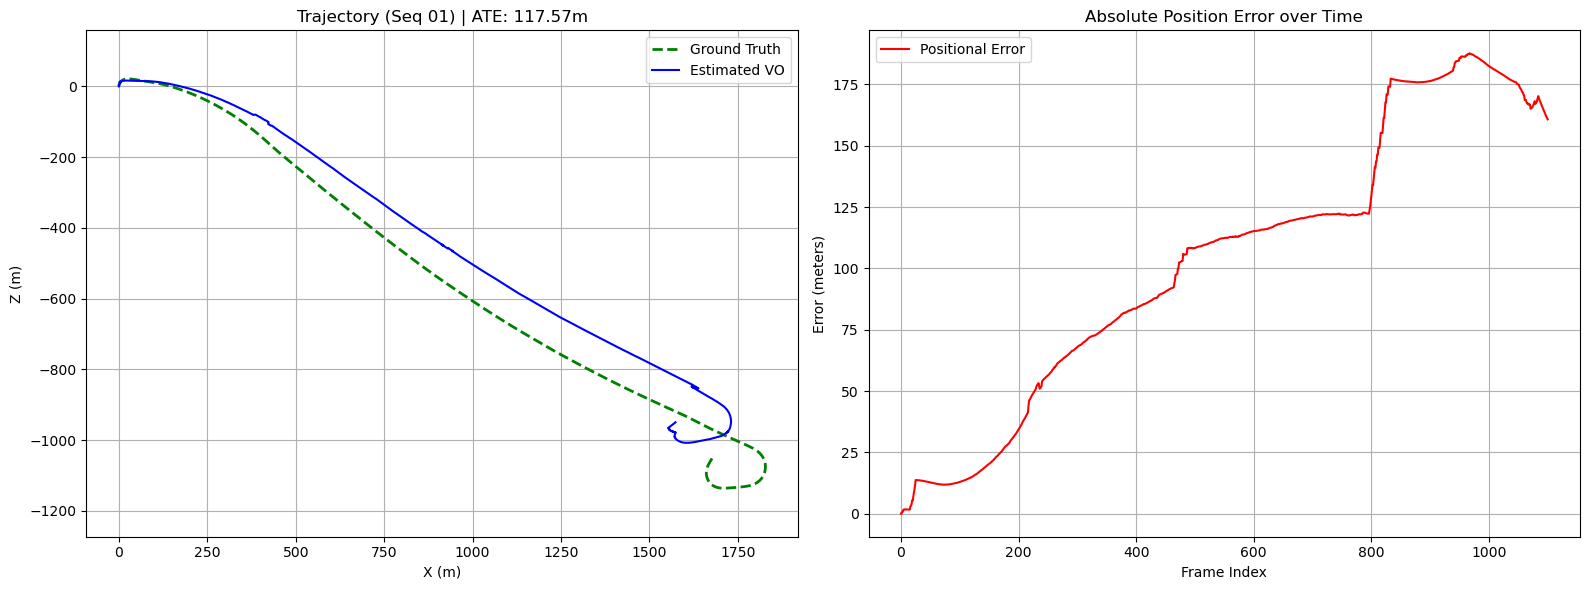

In [10]:
print("\n=== EVALUATION REPORT ===")

# 1. Calculate ATE
ate = compute_ate(gt_poses, est_poses)
print(f"ATE (RMSE): {ate:.4f} meters")

# 2. Calculate RPE for different steps
rpe_1 = compute_rpe(gt_poses, est_poses, delta=1)
rpe_10 = compute_rpe(gt_poses, est_poses, delta=10)
rpe_100 = compute_rpe(gt_poses, est_poses, delta=100)

print(f"RPE (1 frame):   {rpe_1:.4f} m")
print(f"RPE (10 frames): {rpe_10:.4f} m")
print(f"RPE (100 frames):{rpe_100:.4f} m")

# 3. Prepare Data for Plotting
gt_x = [p[0, 3] for p in gt_poses]
gt_z = [p[2, 3] for p in gt_poses]
est_x = [p[0, 3] for p in est_poses]
est_z = [p[2, 3] for p in est_poses]

# 4. Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Trajectory Map
axes[0].plot(gt_x, gt_z, 'g--', label='Ground Truth', linewidth=2)
axes[0].plot(est_x, est_z, 'b', label='Estimated VO', linewidth=1.5)
axes[0].set_title(f"Trajectory (Seq {sequence}) | ATE: {ate:.2f}m")
axes[0].set_xlabel("X (m)")
axes[0].set_ylabel("Z (m)")
axes[0].legend()
axes[0].axis('equal')
axes[0].grid()

# Plot B: Error over time (Distance from GT)
errors = [np.linalg.norm(est_poses[i][:3,3] - gt_poses[i][:3,3]) for i in range(len(est_poses))]
axes[1].plot(errors, 'r', label='Positional Error')
axes[1].set_title("Absolute Position Error over Time")
axes[1].set_xlabel("Frame Index")
axes[1].set_ylabel("Error (meters)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.savefig(f"figures/eval_report.png")
plt.show()